<img src="https://github.com/lid-ufpa/genial/blob/main/assets/genial-logo-banner-dark.png?raw=true" style="width:100%; height:auto;">

# **Aula 1 - Introdução à Otimização Bioinspirada**

Seja bem vindo(a) ao curso **Genetic and Evolutionary Nature-Inspired ALgorithms (GENIAL)**.

Nesta primeira aula, vamos alinhar conceitos-chave, conectar modelagem matemática ao processo de otimização, diferenciar métodos exatos e heurísticos/meta-heurísticos, e dar o primeiro contato com algoritmos bioinspirados.

In [1]:
# !pip install -q pyomo
# !apt install -q -y glpk-utils

from genial.plots import plot_quadratic
from genial.shc import NQueensProblem, StochasticHillClimbing

import pyomo.environ as pyo

from mealpy import FloatVar, GA, ACOR, PSO

## 1.1 Modelagem

### 1.1.1 Conceitos gerais de modelagem

A **modelagem** é o processo de **abstração** de uma situação real para uma representação que permita analisar, simular e resolver um **problema**. Um **modelo** é uma descrição simplificada que captura os elementos essenciais do fenômeno de interesse, preservando estruturas e relações relevantes para uma decisão.

O ciclo de modelagem inclui:
- declaração do problema;
- construção do modelo;
- obtenção da solução;
- validação/ajuste.

![Fluxo de modelagem (01_01_Modelos)](https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula01/fluxo.png?raw=true)

### 1.1.2 Definição de um problema

A etapa de declaração do problema estabelece objetivo, variáveis (de decisão), parâmetros/dados, restrições e critérios de avaliação. Uma formulação imprecisa leva a modelos confusos e a soluções pouco úteis.

- **Objetivo**: minimizar/maximizar uma **função‑objetivo** $f(\cdot)$.
- **Variáveis de decisão**: conjunto $x$ a determinar.
- **Restrições**: relações que $x$ deve satisfazer, na forma de igualdades ou inequações.
- **Dados/Parâmetros**: informações conhecidas e fixas.

### 1.1.3 Soluções

Após definido o problema, formaliza‑se o modelo (por exemplo, um modelo matemático) e escolhe‑se uma estratégia de solução compatível:

- **Solução analítica**: obtida por manipulação simbólica/derivações exatas, quando a estrutura permite. Ex.: encontrar $x^*$ fechando sistema de equações e condições de otimalidade.
- **Solução numérica**: obtida por algoritmos (iterativos, aproximações, busca). Útil quando a solução fechada não é viável. Ex.: métodos de busca, gradiente, ou heurísticas/meta‑heurísticas.

> **Observação**: Nesta disciplina, daremos ênfase a abordagens numéricas por **meta‑heurísticas** (especialmente as **bioinspiradas**), mantendo o vínculo com a modelagem do problema.

Como exemplo, vamos implementar uma solução analítica para resolução de uma função quadrática qualquer por meio da class `Quadratic`.

In [2]:
class Quadratic:
    '''Implementa uma função quadrática f(x) = ax² + bx + c'''
    def __init__(self, a,b,c):
        self.a = a
        self.b = b
        self.c = c

    def solve(self, x):
        return self.a*x**2 + self.b*x + self.c

    def optimum(self):
        '''Encontra o ponto máximo ou mínimo desta função através da fórmula de Bhaskara'''
        delta = self.b**2 - 4*self.a*self.c
        return (- self.b/(2*self.a), -delta/(4*self.a))

    def __str__(self):
        return str(self.a) + "x² + " + str(self.b) + "x + " + str(self.c)

Compare com a implementação da heurística Hill Climbing (Subida da Colina).

In [3]:
def hillClimbing(f, ini, step, which):
    '''O algoritmo da Subida da Colina encontra o valor máximo ou mínimo de uma função
        f: uma função a ser resolvida
        ini: um ponto inicial (float)
        step: o tamanho do passo do algoritmo (float)
        which: uma string 'min' ou 'max'
        '''

    if which == 'min':
        def obj(x):
            return -f(x)
    elif which == 'max':
        def obj(x):
            return f(x)
    else:
        raise Exception()

    actual = ini
    right = ini + step
    left = ini - step

    while (not (obj(actual) > obj(right) and obj(actual) > obj(left))):
        if obj(actual) > obj(right):
            actual = left
        elif obj(actual) < obj(right):
            actual = right
        right = actual + step
        left = actual - step

    return (actual, f(actual))

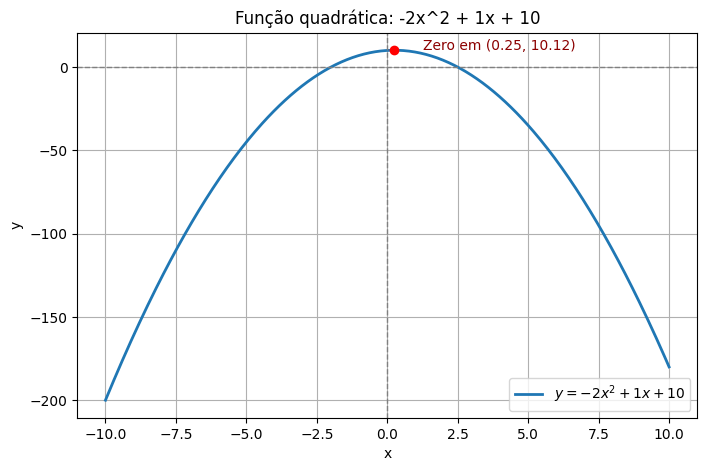

In [4]:
plot_quadratic(-2, 1, 10)

In [5]:
f = Quadratic(-2,1,10)
print(f"Equation: {f}")

(xopt,yopt) = f.optimum()
print(f"Optimum value through analytical solution x={xopt} y={yopt}")

(xopt,yopt) = hillClimbing(f.solve, -40, 0.001, 'max')
print(f"Optimum value through numerical solution x={xopt} y={yopt}")

Equation: -2x² + 1x + 10
Optimum value through analytical solution x=0.25 y=10.125
Optimum value through numerical solution x=0.24999999999748043 y=10.125


In [6]:
f = Quadratic(5,-10,20)
print(f"Equation: {f}")

(xopt,yopt) = f.optimum()
print(f"Optimum value through analytical solution x={xopt} y={yopt}")

(xopt,yopt) = hillClimbing(f.solve, -40, 0.001, 'min')
print(f"Optimum value through numerical solution x={xopt} y={yopt}")

Equation: 5x² + -10x + 20
Optimum value through analytical solution x=1.0 y=15.0
Optimum value through numerical solution x=0.999999999997481 y=15.0


## 1.2 Teoria da Complexidade e Motivação para a Otimização

A **Teoria da Complexidade Computacional** busca classificar problemas de acordo a quantidade de recursos necessários para resolvê‑los, especialmente **tempo** e **memória**. Essa teoria ajuda a compreender **por que** muitas vezes é inviável obter soluções exatas para certos problemas e **por que** precisamos de técnicas de **otimização aproximada**.

### 1.2.1 Classes de problemas

Os problemas computacionais são agrupados em **classes de complexidade**, conforme o esforço necessário para resolvê‑los:

- **P (Polinomial)**: problemas resolvíveis em tempo razoável, com algoritmos cujo tempo cresce de forma polinomial com o tamanho da entrada. Ex.: ordenação de listas, busca binária.
- **NP (Não‑determinístico Polinomial)**: problemas para os quais **verificar** uma solução é fácil (tempo polinomial), mas **encontrá‑la** pode ser difícil. Ex.: caixeiro viajante, colorir grafos, mochila.
- **NP‑completo**: subclasse de NP que representa os problemas mais difíceis dessa categoria; se encontrarmos uma solução eficiente para um deles, resolveremos todos os outros.
- **NP‑difícil (NP‑hard)**: problemas ainda mais gerais, que podem nem pertencer a NP (nem ser verificáveis em tempo polinomial), mas cuja solução é pelo menos tão difícil quanto a de um NP‑completo.

![](https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula01/pnp.png?raw=true)

### 1.2.2 Crescimento de Complexidade e Escalabilidade

Para pequenos tamanhos de entrada ($n$), até métodos exatos funcionam bem. Contudo, o crescimento exponencial do número de combinações em muitos problemas faz com que algoritmos exatos se tornem inviáveis para instâncias reais. O gráfico abaixo ilustra como o tempo cresce conforme $n$ aumenta, comparando ordens de complexidade: $O(n)$, $O(n^2)$, $O(2^n)$ etc.

<img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula01/classes.jpg?raw=true" style="width:700px; height:auto;">


### 1.2.3 Da complexidade à otimização

Essas limitações justificam o uso de técnicas de otimização que visam encontrar boas soluções, mesmo que não sejam ótimas globais. A escolha do método depende do tipo de problema:

* Para problemas **P**, métodos **exatos** são suficientes.
* Para problemas **NP‑difíceis**, busca‑se **heurísticas** e **meta‑heurísticas** que forneçam soluções **aproximadas** em tempo viável.

Assim, compreender a complexidade de um problema é essencial para escolher a estratégia de otimização adequada.

## 1.3 O que é Otimização?

<img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula01/stop-study.jpg?raw=true" style="width:100%; height:auto;">

A **otimização** permeia as nossas vidas sem nem percebermos. Estamos constantemente otimizando coisas, desde calcular a rota mais curta entre a sua casa até um ponto de ônibus até a montagem de um cronograma de estudos para maximizar o aprendizado em um tempo limitado. Tudo isso é **otimização**.

Conceituamente, a otimização busca a **melhor** solução possível para um problema conforme um **critério** (função‑objetivo) e **restrições**.

De forma simples, a otimização se baseia em encontrar a **melhor solução** possível para um problema, dadas certas limitações ou regras.

Muitos problemas podem ser formulados como problemas de otimização:

- **Maximize** a eficiência, lucro, qualidade, sustentabilidade... 
- **Minimize** o uso de combustível, tempo, custo, distância de uma viagem... 

### 1.3.1 Componentes de um Problema de Otimização

<img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula01/knapsack.png?raw=true" style="width:100%; height:auto;">

Todo problema de otimização possui 3 componentes principais, são eles:

- **Variáveis de decisão:** são os valores do problema que podem ser **controlados** e **alterados**.

- **Função objetivo:** é uma expressão matemática que traduz o objetivo principal do modelo. É ela que queremos **otimizar**, ou seja, **maximizar** ou **minimizar**.

- **Restrições:** são **regras, limitações ou condições** que a solução do problema deve obedecer.

Vamos exemplificar esses conceitos usando o **problema da mochila**, que é um problema clássico da otimização e que nós iremos resolver na próxima aula.

Imagine que você tenha um mochila e que queira colocar o máximo de objetos nela sem que ela rasgue, ou seja, o peso total dos objetos deve ser menor do que o peso máximo suportado pela mochila, cada um desses objetos tem um valor de importância e um peso específico.

Podemos modelar essa situação da seguinte forma:

- **Problema:** quais itens se deve colocar na mochila?
- **Variáveis de decisão:** para cada objeto, a decisão será "levar" ou "não levar".
- **Função objetivo:** maximizar o valor total de importância dos objetos que estão na mochila.
- **Restrição:** o peso total dos objetos presentes na mochila deve ser menor do que o máximo suportado pela mochila. 

---

## 1.4 Métodos Exatos e Heurísticos

Quando se trata de problemas de otimização, existem duas abordagem principais: métodos **exatos** e **heurísticos**.

### 1.4.1 Métodos Exatos

Os métodos exatos são aqueles que garantem encontrar a melhor solução possível para um problema, a chamada **"solução ótima"**. Eles fazem isso explorando de forma completa e sistemática todo o espaço de soluções viáveis. Exemplos de métodos exatos incluem programação linear, programação linear inteira, condições de convexidade, branch‑and‑bound.

**Características Principais:**

- **Garantia de otimalidade**: se uma solução é encontrada, você tem 100% de certeza de que ela é a melhor possível.

- **Completude**: consegue provar que não existe nenhuma solução melhor do que a que foi encontrada.

- **Custo computacional elevado**: a principal desvantagem é que, para problemas **complexos e de grande escala**, o tempo necessário para encontrar a solução ótima pode crescer **exponencialmente**, tornando-se inviável na prática. Pode levar horas, dias ou até mesmo séculos.

#### Exemplo

<img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula01/fazendeiro.png?raw=true" style="width:300px; height:auto;">

Um fazendeiro possui 100 acres de terra e está planejando cultivar açaí e cupuaçú.

- Cada acre cultivado com açaí gera um lucro de R$ 550, requer 3 trabalhadores e 5 toneladas de fertilizante.
- Cada acre cultivado com cupuaçú gera um lucro de R$ 400, requer 4 trabalhadores e 3 toneladas de fertilizante.

O fazendeiro pode contratar até 300 trabalhadores e armazenar até 400 tons de fertilizante. Modele o problema e crie um modelo de otimização que maximize o lucro total.

- Variáveis de decisão: $A$ (acres de açaí) e $C$ (acres de cupuaçú)
- Função objetivo: $max(lucro) = 550A + 400C$
- Restrições: sujeito a $\left\{
\begin{array}{ll}
    A + C \leq 100, \\
    3A + 4C \leq 300, \\
    5A + 3C \leq 400,\\
    A \geq 0, \\
    C \geq 0.
\end{array}
\right.$

Em seguida, criamos o modelo, adicionando as variáveis e restrições. A biblioteca PyOMO que contém ferramentas para criar e resolver modelos de otimização usando Python.

In [7]:
model_farm = pyo.ConcreteModel()

model_farm.acai = pyo.Var(within=pyo.NonNegativeReals)
model_farm.cupuacu = pyo.Var(within=pyo.NonNegativeReals)

model_farm.profit = pyo.Objective(expr=550*model_farm.acai + 400*model_farm.cupuacu, sense=pyo.maximize)

model_farm.land_constraint = pyo.Constraint(expr=model_farm.acai + model_farm.cupuacu <= 100)
model_farm.worker_constraint = pyo.Constraint(expr=3*model_farm.acai + 4*model_farm.cupuacu <= 300)
model_farm.fertilizer_constraint = pyo.Constraint(expr=5*model_farm.acai + 3*model_farm.cupuacu <= 400)

Utilizando o solver, obtemos o resultado ótimo e a validação das restrições.

In [8]:
solver = pyo.SolverFactory('glpk')
result_farm = solver.solve(model_farm)

model_farm.display()

Model unknown

  Variables:
    acai : Size=1, Index=None
        Key  : Lower : Value            : Upper : Fixed : Stale : Domain
        None :     0 : 63.6363636363636 :  None : False : False : NonNegativeReals
    cupuacu : Size=1, Index=None
        Key  : Lower : Value            : Upper : Fixed : Stale : Domain
        None :     0 : 27.2727272727273 :  None : False : False : NonNegativeReals

  Objectives:
    profit : Size=1, Index=None, Active=True
        Key  : Active : Value
        None :   True : 45909.0909090909

  Constraints:
    land_constraint : Size=1
        Key  : Lower : Body              : Upper
        None :  None : 90.90909090909089 : 100.0
    worker_constraint : Size=1
        Key  : Lower : Body  : Upper
        None :  None : 300.0 : 300.0
    fertilizer_constraint : Size=1
        Key  : Lower : Body              : Upper
        None :  None : 399.9999999999999 : 400.0


In [9]:
result_farm.write()

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 45909.0909090909
  Upper bound: 45909.0909090909
  Number of objectives: 1
  Number of constraints: 3
  Number of variables: 2
  Number of nonzeros: 6
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  Termination condition: optimal
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: 0
      Number of created subproblems: 0
  Error rc: 0
  Time: 0.0015916824340820312
# ----------------------------------------------------------
#   Solution Information
# -------------

### 1.4.2 Métodos Heurísticos

Para muitos problemas de otimização, o espaço de soluções possíveis é tão vasto que explorá-lo completamente com métodos exatos é **computacionalmente inviável**. Embora garantam encontrar a solução ótima, esses métodos levariam um tempo impraticável, em alguns casos, **bilhões de anos**, tornando impossível sua utilização para obter uma resposta em tempo hábil.

Assim, recorremos aos métodos **heurísticos**. Uma heurística serve como uma espécie de "guia" para a busca explorar as regiões mais promissoras no espaço de soluções viáveis e encontrar uma **"boa solução"** em um tempo útil para um problema. Eles não garantem encontrar a solução ótima, mas são extremamente úteis na prática.

**Características Principais:**

- **Tempo**: são projetados para encontrar uma boa solução em um tempo útil.
- **Sem garantia de otimalidade**: a solução encontrada por um método heurístico nem sempre é a melhor solução possível.
- **Estocástico**: muitas heurísticas possuem elementos de aleatoridade.

#### Exemplo

<img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula01/eight-queens-encoding-genial.png?raw=true" style="width:900px; height:auto;">

Um agricultor familiar quer aproveitar ao máximo um terreno dividido em 8 talhões quadrados por 8 talhões quadrados (uma grade 8×8). Ele pretende cultivar oito espécies típicas da Amazônia, como açaí, cupuaçu, cacau, pimenta-do-reino, mandioca, urucum, andiroba e castanha-do-pará.

Porém, algumas dessas espécies liberam substâncias nas raízes, no ar ou no solo que afetam o crescimento de outras se forem plantadas muito próximas, especialmente na mesma linha, coluna ou diagonal do terreno, onde o vento e a drenagem do solo favorecem o contato entre elas.

O desafio do agricultor é distribuir as oito culturas de modo que:

- Cada tipo de planta ocupe exatamente um talhão em cada linha e coluna;
- Nenhuma cultura interfira com outra ao longo das diagonais do terreno;
- Todo o espaço seja utilizado de forma sustentável e equilibrada.

Este é o caso do problema das oito rainhas, onde o objetivo é dispor as peças em um tabuleiro de forma que nenhuma se ataque.

Vamos usar um módulo implementado para a definição do problema das oito rainhas e para a heurística do Stochastic Hill Climbing

Em seguida, criamos uma instância do problema e definimos parâmetros de número máximo de iterações, reinicializações aleatórias e limiares de iterações sem melhoria.

In [10]:
problem = NQueensProblem(N=8, seed=42)

optimizer = StochasticHillClimbing(
    objective_fn=problem.objective,
    neighbor_fn=problem.neighbor,
    random_state_fn=problem.random_state,
    maximize=True,
    max_iters=50_000,
    restarts=20,
    no_improve_limit=2_000,
)

Ao executar a otimização, obtemos o custo (custo zero caso nenhuma plantação interfira com a outra) e a configuração do terreno.

In [11]:
best_state, best_score = optimizer.run()

print("Best score:", best_score)
print("Best state:", best_state)
print("\nBoard:\n")
print(problem.pretty_board(best_state))

Best score: -0.0
Best state: [2, 5, 7, 0, 3, 6, 4, 1]

Board:

· · Q · · · · ·
· · · · · Q · ·
· · · · · · · Q
Q · · · · · · ·
· · · Q · · · ·
· · · · · · Q ·
· · · · Q · · ·
· Q · · · · · ·


---

## 1.5 O que são as Meta-heurísticas?

Vimos que as heurísticas são como "guias" para encontrar boas soluções. Entretanto, uma heurística simples pode ficar facilmente presa em ótimos locais. 

Desse modo, recorremos às **meta-heurísticas**. Uma meta-heurística é uma estratégia de "alto nível" que orienta outras heurísticas para que elas explorem o espaço de busca de forma mais eficente, evitando ótimos locais.

Muitas das meta-heurísticas foram inspiradas em processos biológicos, físicos ou outros fenômenos bioinspirados.

### 1.5.1 Exploration e Exploitation

É importante entender que as meta-heurísticas buscam equilibrar dois fatores: **_exploration_ (diversificação)** e **_exploitation_ (intensificação)**.

1. **Exploration (diversificação)**

A diversificação é a capacidade de **explorar várias regiões diferentes entre si no espaço de busca**. Assim, dando mais variedade às soluções e evitando que elas fiquem presas em uma única região.

2. **Exploitation (intensificação)**

A intensificação é a capacidade de **dar enfoque na busca em uma região mais promissora que já foi encontrada**. Desse modo, refinando as boas soluções já conhecidas para encontrar melhores soluções nas proximidades.

Um bom algoritmo meta-heurístico consegue explorar uma variedade de regiões e dar enfoque naquela mais promissora.

<img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula01/pso.gif?raw=true" style="width:600px; height:auto;">

---

## 1.6 Algoritmos Bioinspirados

Os **algoritmos bioinspirados** são uma classe de meta-heurísticas que se baseiam em fenômenos naturais, como o processo de seleção natural de Darwin e o comportamento coletivo de bandos de passáros e cardumes de peixes. Esses algoritmos são usados para resolver uma gama de problemas, desde a engenharia até a computação. 

Vamos dar uma breve explorada nos algoritmos que veremos nas próximas aulas.

Para mostrar como os algoritmos bio-inspirados podem ser utilizados, usaremos o **MNIST**, um conjunto de 70 mil imagens 28×28 em tons de cinza de dígitos de 0 a 9, como base para treinarmos um modelo **SVC** (Support Vector Classifier) com para aprender fronteiras de decisão capazes de distinguir os dígitos.

<img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula01/mnist.png?raw=true" style="width:600px; height:auto;">

Os hiperparâmetros críticos do SVC são **C** (controle da margem/regularização) e **gamma** (alcance do kernel). Para extrair bons valores de forma sistemática, aplicaremos as estratégias bio-inspiradas do curso usando a biblioteca **Mealpy**. Cada estratégia buscará maximizar a **acurácia média de validação cruzada** (por exemplo, 3-fold) sobre um espaço contínuo definido em termos de **log10(C)** e **log10(gamma)**, garantindo comparabilidade e estabilidade.

Ao final da busca, reentreinaremos o SVC com os melhores hiperparâmetros no conjunto de treino completo e avaliaremos no teste, reportando a acurácia final. Esse arranjo demonstra, de forma concisa, como integrar um classificador clássico (SVC) a **meta-heurísticas** para otimização de hiperparâmetros.


In [12]:
from sklearn.datasets import fetch_openml
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# carregamento dos dados
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X, y = mnist.data.astype("float32"), mnist.target.astype("int64")

# normalização simples e embaralhamento
X /= 255.0
rng = np.random.RandomState(42)
perm = rng.permutation(X.shape[0])
X, y = X[perm], y[perm]

# divisão fixa entre treino e teste (1k teste)
X_train, X_test = X[:1000], X[1000:]
y_train, y_test = y[:1000], y[1000:]

In [13]:
svm_clf = SVC(kernel="rbf", C=50, gamma=0.5, class_weight="balanced")
svm_clf.fit(X_train, y_train)
svm_pred = svm_clf.predict(X_test)
print(f"SVM (RBF) accuracy: {accuracy_score(y_test, svm_pred):.4f}")

SVM (RBF) accuracy: 0.1359


### 1.6.1 Algoritmos Genéticos (GA)

<img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula01/genetic.jpg?raw=true" style="width:100%; height:auto;">

Inspirados na **teoria da evolução de Charles Darwin**. As soluções "competem" entre si, e as mais "aptas" sobrevivem, se reproduzem e geram novas soluções, melhorando a qualidade geral a cada "geração".

Vamos iniciar a implementação da otimização bio-inspirada criando uma função objetivo que possa maximizar o valor das médias da validação-cruzada. Essa função também será usada para os demais modelos (ACO e PSO).

In [14]:
def svm_cv_objective(sol_vec):
    logC, logG = float(sol_vec[0]), float(sol_vec[1])
    C = 10.0 ** logC
    gamma = 10.0 ** logG
    model = SVC(kernel="rbf", C=C, gamma=gamma, class_weight="balanced")
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    return float(scores.mean())

Em seguida defimos as restrições, o problema e instanciamos o modelo de Algoritmo Genético da biblioteca Mealpy.

In [15]:
# restrições dos parâmetros (log10 scale)
bounds = FloatVar(lb=(-2.0, -6.0), ub=(3.0, 0.0), name="log10_params")

# definição do problema
problem = {
    "obj_func": svm_cv_objective,
    "bounds": bounds,
    "minmax": "max",
    "log_to": "console",
    "name": "SVM_RBF_CV_Acc",
}

# instanciando o modelo de Algoritmo Genético
ga = GA.OriginalGA(
    epoch=15,                 # generations
    pop_size=10,              # population size
    pc=0.9,                   # crossover prob
    pm=0.05,                  # mutation prob
    selection="tournament",
    crossover="uniform",
    mutation="flip",
    k_way=0.2,                # tournament fraction
)

Com estas configurações em mãos, podemos resolver o problema e obter os melhores valores de C e Gamma para o SVC, segundo o AG.

In [16]:
ag_g_best = ga.solve(problem)
ag_best_logC, ag_best_logG = ag_g_best.solution
ag_best_C, ag_best_gamma = 10.0 ** ag_best_logC, 10.0 ** ag_best_logG
ag_best_cv = ag_g_best.target.fitness
print(f"[GA] Best (CV acc={ag_best_cv:.4f}) -> C={ag_best_C:.6g}, gamma={ag_best_gamma:.6g}")

2025/10/10 11:48:48 AM, INFO, mealpy.evolutionary_based.GA.OriginalGA: OriginalGA(epoch=15, pop_size=10, pc=0.9, pm=0.05, selection=tournament, crossover=uniform, mutation=flip, k_way=0.2, mutation_multipoints=True)
2025/10/10 11:48:54 AM, INFO, mealpy.evolutionary_based.GA.OriginalGA: >>>Problem: SVM_RBF_CV_Acc, Epoch: 1, Current best: 0.9000017982053911, Global best: 0.9000017982053911, Runtime: 0.00018 seconds
2025/10/10 11:48:54 AM, INFO, mealpy.evolutionary_based.GA.OriginalGA: >>>Problem: SVM_RBF_CV_Acc, Epoch: 2, Current best: 0.9000017982053911, Global best: 0.9000017982053911, Runtime: 0.00054 seconds
2025/10/10 11:48:54 AM, INFO, mealpy.evolutionary_based.GA.OriginalGA: >>>Problem: SVM_RBF_CV_Acc, Epoch: 3, Current best: 0.9000017982053911, Global best: 0.9000017982053911, Runtime: 0.00024 seconds
2025/10/10 11:48:54 AM, INFO, mealpy.evolutionary_based.GA.OriginalGA: >>>Problem: SVM_RBF_CV_Acc, Epoch: 4, Current best: 0.9000017982053911, Global best: 0.9000017982053911, Runti

[GA] Best (CV acc=0.9000) -> C=5.5726, gamma=0.0201253


Aplicando os hiperparâmetros obtidos de volta no SVC, obtemos melhorias na acurácia geral.

In [17]:
ag_svm_best = SVC(kernel="rbf", C=ag_best_C, gamma=ag_best_gamma, class_weight="balanced")
ag_svm_best.fit(X_train, y_train)
ag_test_pred = ag_svm_best.predict(X_test)
print(f"[Test] Accuracy with GA: {accuracy_score(y_test, ag_test_pred):.4f}")

[Test] Accuracy with GA: 0.9246


### 1.6.2 Otimização por Colônia de Formigas (ACO)

<img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula01/ants.jpg?raw=true" style="width:100%; height:auto;">

Inspirada no **comportamento de formigas buscando comida**. As formigas depositam feromônios para marcar os melhores caminhos, e com o tempo, a colônia converge para a rota mais curta entre o ninho e a fonte de alimento.

Vamos usar instanciar o moddelo ACO para problemas contínuos da biblioteca Mealpy.

In [18]:
# instanciando o modelo de Ant Colony Optimization

aco = ACOR.OriginalACOR(
    epoch=15,            # iterations (generations)
    pop_size=10,         # archive size (solution memory)
    sample_count=12,     # number of samples per iteration
    intent_factor=0.5,   # xi
    zeta=1.0,            # zeta
)

Podemos então resolver o problema e obter os hiperparâmetros desejados.

In [19]:
aco_g_best = aco.solve(problem)
aco_best_logC, aco_best_logG = aco_g_best.solution
aco_best_C, aco_best_gamma = 10.0 ** aco_best_logC, 10.0 ** aco_best_logG
aco_best_cv = aco_g_best.target.fitness
print(f"[ACOR] Best (CV acc={aco_best_cv:.4f}) -> C={aco_best_C:.6g}, gamma={aco_best_gamma:.6g}")

2025/10/10 11:49:07 AM, INFO, mealpy.swarm_based.ACOR.OriginalACOR: OriginalACOR(epoch=15, pop_size=10, sample_count=12, intent_factor=0.5, zeta=1.0)
2025/10/10 11:49:13 AM, INFO, mealpy.swarm_based.ACOR.OriginalACOR: >>>Problem: SVM_RBF_CV_Acc, Epoch: 1, Current best: 0.900996805188422, Global best: 0.900996805188422, Runtime: 3.37923 seconds
2025/10/10 11:49:16 AM, INFO, mealpy.swarm_based.ACOR.OriginalACOR: >>>Problem: SVM_RBF_CV_Acc, Epoch: 2, Current best: 0.900996805188422, Global best: 0.900996805188422, Runtime: 3.03061 seconds
2025/10/10 11:49:19 AM, INFO, mealpy.swarm_based.ACOR.OriginalACOR: >>>Problem: SVM_RBF_CV_Acc, Epoch: 3, Current best: 0.900996805188422, Global best: 0.900996805188422, Runtime: 2.87459 seconds
2025/10/10 11:49:22 AM, INFO, mealpy.swarm_based.ACOR.OriginalACOR: >>>Problem: SVM_RBF_CV_Acc, Epoch: 4, Current best: 0.9010027992063919, Global best: 0.9010027992063919, Runtime: 2.99083 seconds
2025/10/10 11:49:25 AM, INFO, mealpy.swarm_based.ACOR.OriginalAC

[ACOR] Best (CV acc=0.9040) -> C=146.294, gamma=0.0287276


Novamente, obtemos melhorias na acurácia ao usar o algoritmo bio-inspirado.

In [20]:
aco_svm_best = SVC(kernel="rbf", C=aco_best_C, gamma=aco_best_gamma, class_weight="balanced")
aco_svm_best.fit(X_train, y_train)
aco_test_pred = aco_svm_best.predict(X_test)
print(f"[Test] Accuracy with ACO: {accuracy_score(y_test, aco_test_pred):.4f}")

[Test] Accuracy with ACO: 0.9244


### 1.6.3 Otimização por Enxame de Partículas (PSO)

<img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula01/birds.jpg?raw=true" style="width:100%; height:auto;">

Inspirada no **comportamento de cardumes de peixes ou bandos de pássaros**. Partículas (soluções) "voam" pelo espaço de busca, compartilhando informações entre si para encontrar a melhor posição (a solução ótima).

Usando PSO, vamos instanciar um novo modelo.

In [21]:
pso = PSO.OriginalPSO(
    epoch=15,       # iterations
    pop_size=10,    # swarm size
    c1=1.8,
    c2=1.8,
    w=0.72,
)

Os melhores hiperparâmetros são obtidos, a partir da resolução via PSO.

In [22]:
pso_g_best = pso.solve(problem)
pso_best_logC, pso_best_logG = pso_g_best.solution
pso_best_C, pso_best_gamma = 10.0 ** pso_best_logC, 10.0 ** pso_best_logG
pso_best_cv = pso_g_best.target.fitness
print(f"[PSO] Best (CV acc={pso_best_cv:.4f}) -> C={pso_best_C:.6g}, gamma={pso_best_gamma:.6g}")

2025/10/10 11:50:10 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=15, pop_size=10, c1=1.8, c2=1.8, w=0.72)
2025/10/10 11:50:15 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: SVM_RBF_CV_Acc, Epoch: 1, Current best: 0.900996805188422, Global best: 0.900996805188422, Runtime: 2.37437 seconds
2025/10/10 11:50:17 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: SVM_RBF_CV_Acc, Epoch: 2, Current best: 0.9019978061894229, Global best: 0.9019978061894229, Runtime: 2.58225 seconds
2025/10/10 11:50:20 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: SVM_RBF_CV_Acc, Epoch: 3, Current best: 0.9019978061894229, Global best: 0.9019978061894229, Runtime: 2.58080 seconds
2025/10/10 11:50:23 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: SVM_RBF_CV_Acc, Epoch: 4, Current best: 0.9019978061894229, Global best: 0.9019978061894229, Runtime: 2.56572 seconds
2025/10/10 11:50:25 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: SVM_RBF_CV_Acc,

[PSO] Best (CV acc=0.9040) -> C=685.316, gamma=0.0295959


E assim, obtemos novas melhorias no modelo SVC.

In [23]:
pso_svm_best = SVC(kernel="rbf", C=pso_best_C, gamma=pso_best_gamma, class_weight="balanced")
pso_svm_best.fit(X_train, y_train)
pso_test_pred = pso_svm_best.predict(X_test)
print(f"[Test] Accuracy: {accuracy_score(y_test, pso_test_pred):.4f}")

[Test] Accuracy: 0.9243


## 1.7 A metáfora exposta das meta-heurísticas

A metáfora nas meta-heurísticas, conforme discutido por **Kenneth Sörensen (2013)**, representa uma forma criativa, mas também arriscada, de justificar novos algoritmos a partir de processos naturais ou sociais. Embora analogias como colônias de formigas, evolução genética ou o resfriamento de metais tenham originado métodos relevantes, a proliferação de meta-heurísticas baseadas em metáforas superficiais tem afastado a área do rigor científico.

### 1.7.1 Riscos associados

- **Reinvenção de conceitos**: muitos algoritmos “novos” apenas renomeiam mecanismos já existentes.
- **Vocabulário opaco**: o uso de termos da metáfora (ex.: notas, colmeias, gotas de água) dificulta a comunicação e comparação entre métodos.
- **Foco no desempenho e não na compreensão**: a busca por resultados superiores em *benchmarks* substitui a investigação das causas do bom desempenho.
- **Perda de credibilidade científica**: o excesso de “novidades” reduz o valor das contribuições realmente inovadoras.

### 1.7.2 Perspectivas de pesquisa

Sörensen propõe um retorno à **compreensão estrutural** dos problemas e ao desenvolvimento de meta-heurísticas **componentizadas**, fundamentadas em princípios claros e testáveis. Pesquisas de qualidade devem:

- Decompor algoritmos em seus **operadores e componentes**, analisando o papel de cada um;
- Utilizar **linguagem unificada** de otimização, evitando jargões da metáfora;
- Combinar **heurísticas** e **métodos exatos** de forma integrada (*matheuristics*);
- Adotar **testes estatísticos e comparações transparentes** para avaliar desempenho.

# Referências bibliográficas

- GASPAR-CUNHA, A.; TAKAHASHI, R.; ANTUNES, C. H. Manual de Computação Evolutiva e Metaheurística. Editora UFMG. 2013.
- TALBI, E. Metaheuristics. Wiley-Blackwell. 2009.
- GENDREAU, M.; POTVIN, J. Handbook of Metaheuristics. Springer, 2010.
- FOGEL, D. B.; MICHALEWICZ, Z. How to Solve It: Modern Heuristics. 2nd Edition. 2013.
- SARKER, Ruhul Amin; NEWTON, Charles S. Optimization modelling: a practical approach. CRC press, 2007.
- YANG, Xin-She. Nature-inspired optimization algorithms. Academic Press, 2020.
- FLOREANO, Dario; MATTIUSSI, Claudio. Bio-Inspired Artificial Intelligence: Theories, Methods, and Technologies. MIT Press, 2023.
- Sörensen, K. Metaheuristics—the metaphor exposed. International Transactions in Operational Research. 2013.
- IEEE Congress on Evolutionary Computation (IEEE CEC): https://ieeexplore.ieee.org/xpl/conhome/1000284/all-proceedings
- Genetic and Evolutionary Computation Conference (GECCO): https://dl.acm.org/doi/proceedings/10.1145/3638529